In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from collections import Counter

In [3]:
def generate_harder_spiral_data(points_per_class=200, noise=0.4, num_classes=3, random_state=42):
    rng = np.random.RandomState(random_state)
    N = points_per_class
    D = 2
    K = num_classes
    X = np.zeros((N*K, D))
    y = np.zeros(N*K, dtype='uint8')

    for j in range(K):
        ix = range(N*j, N*(j+1))
        r = np.linspace(0.0, 1, N)
        t = np.linspace(j*4, (j+1)*4, N) + rng.randn(N)*noise
        X[ix] = np.c_[r * np.sin(t), r * np.cos(t)]
        y[ix] = j

    return X, y

In [4]:
X, y = generate_harder_spiral_data()
print(X.shape, y.shape)

(600, 2) (600,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (480, 2) (480,)
Test : (120, 2) (120,)


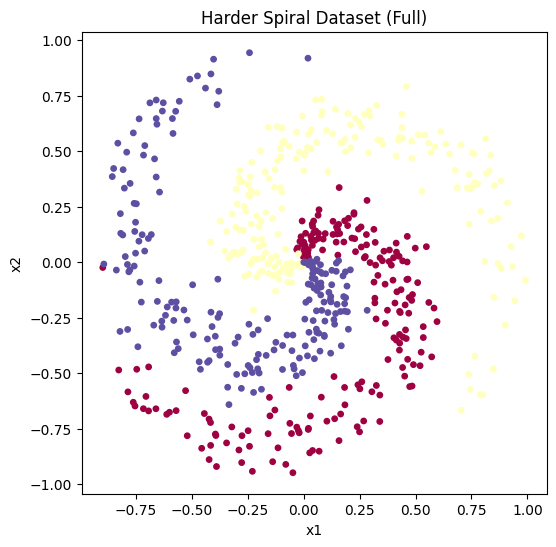

In [6]:
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap="Spectral", s=15)
plt.title("Harder Spiral Dataset (Full)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

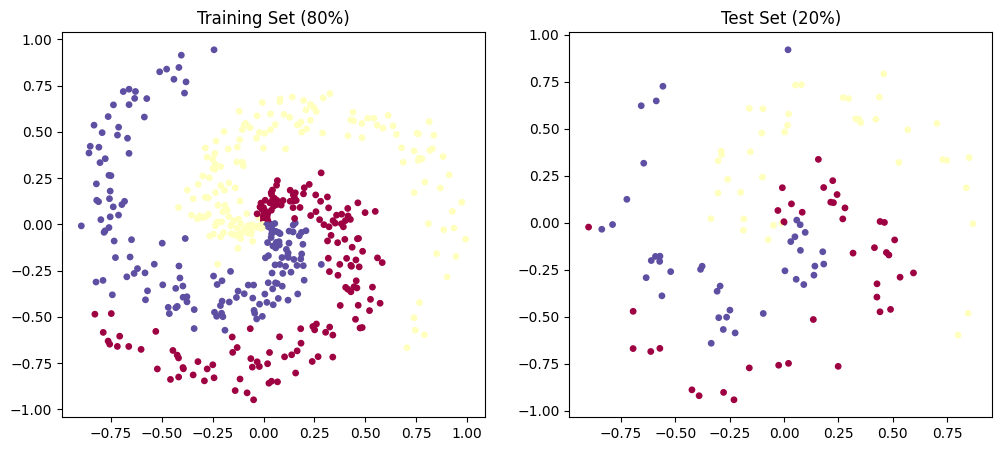

In [7]:
plt.figure(figsize=(12,5))

# Train
plt.subplot(1,2,1)
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap="Spectral", s=15)
plt.title("Training Set (80%)")

# Test
plt.subplot(1,2,2)
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap="Spectral", s=15)
plt.title("Test Set (20%)")

plt.show()

In [8]:

# Step 2 Model building

# Import Keras components
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# -------------------------------------------
# 1. Build the model
# We use a simple MLP with two hidden layers.
# This is baseline

model = Sequential([

    # First hidden layer with 64 neurons and ReLU activation
    Dense(64, activation='relu', input_shape=(2,)),

    # Second hidden layer with 64 neurons and ReLU activation
    Dense(64, activation='relu'),

    # Output layer with 3 neurons (since we have 3 classes)
    # Softmax gives probability distribution
    Dense(3, activation='softmax')
])

# Show model architecture
model.summary()

# 2. Compile the model

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Train the model

history = model.fit(
    X_train, y_train,
    epochs=300,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)
pl

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,547 (17.76 KB)

 Trainable params: 4,547 (17.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.3310 - loss: 1.0920 - val_accuracy: 0.3646 - val_loss: 1.0688
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3930 - loss: 1.0579 - val_accuracy: 0.5000 - val_loss: 1.0420
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4555 - loss: 1.0377 - val_accuracy: 0.4896 - val_loss: 1.0177
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4862 - loss: 1.0144 - val_accuracy: 0.5104 - val_loss: 0.9940
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5299 - loss: 0.9850 - val_accuracy: 0.5208 - val_loss: 0.9706
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5244 - loss: 0.9663 - val_accuracy: 0.5208 - val_loss: 0.9476
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5142 - loss: 0.9397 - val_accuracy: 0.5208 - val_loss: 0.9241
Epoch 8/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5314 - loss: 0.9047 - val_accuracy: 0.5104 - val_loss:

NameError: name 'pl' is not defined

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,547 (17.76 KB)

 Trainable params: 4,547 (17.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.2785 - loss: 1.1112 - val_accuracy: 0.4583 - val_loss: 1.0803
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4654 - loss: 1.0786 - val_accuracy: 0.4896 - val_loss: 1.0528
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5349 - loss: 1.0488 - val_accuracy: 0.5208 - val_loss: 1.0261
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5259 - loss: 1.0209 - val_accuracy: 0.5521 - val_loss: 1.0009
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5112 - loss: 0.9944 - val_accuracy: 0.5417 - val_loss: 0.9764
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5319 - loss: 0.9676 - val_accuracy: 0.5417 - val_loss: 0.9516
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5349 - loss: 0.9405 - val_accuracy: 0.5312 - val_loss: 0.9267
Epoch 8/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5445 - loss: 0.9136 - val_accuracy: 0.5312 - val_loss:

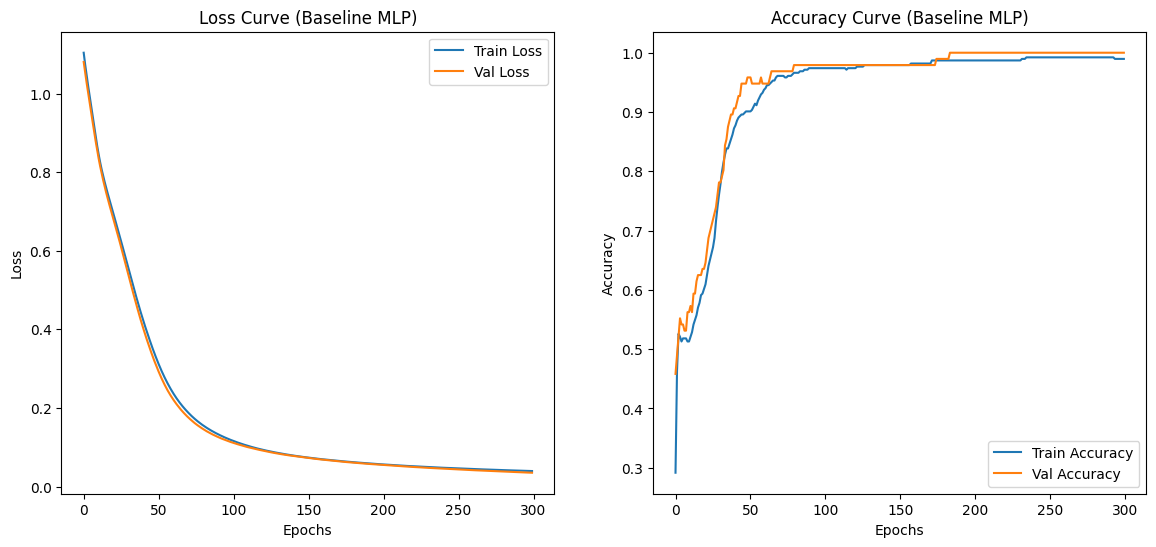

In [11]:
# STEP 2: Build, compile and train the baseline MLP using Keras
# This cell assumes X_train, y_train are already defined (from Step 1).

# Imports for Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Set a reproducible seed (optional)
tf.random.set_seed(42)
np.random.seed(42)

# Build the baseline model:
# - Input: 2 features
# - Hidden: 2 layers x 64 units each with ReLU
# - Output: 3 units with softmax
model = Sequential([
    Dense(64, activation='relu', input_shape=(2,)),  # hidden layer 1
    Dense(64, activation='relu'),                    # hidden layer 2
    Dense(3, activation='softmax')                   # output layer for 3 classes
])

# Display the model summary (params, layers)
model.summary()

# Compile the model:
# - optimizer: Adam (lr=0.001)
# - loss: sparse_categorical_crossentropy (labels are integers 0,1,2)
# - metric: accuracy
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model:
# - epochs: 300 (as recommended by assignment)
# - batch_size: 64
# - validation_split: 0.2 (20% of training data used for validation)
history = model.fit(
    X_train, y_train,
    epochs=300,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# Plot training and validation loss & accuracy
plt.figure(figsize=(14,6))

# Loss plot
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curve (Baseline MLP)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Curve (Baseline MLP)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


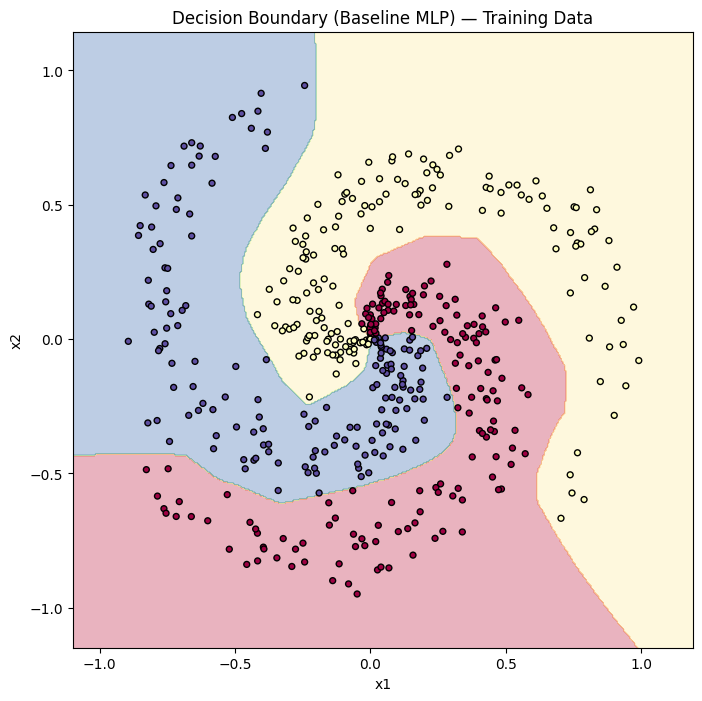

Test Loss: 0.3518
Test Accuracy: 0.9583


In [10]:
# STEP 3: Decision boundary visualization and test evaluation

import numpy as np
import matplotlib.pyplot as plt

# Create a 2D grid that covers the area of the data
x_min, x_max = X[:,0].min() - 0.2, X[:,0].max() + 0.2
y_min, y_max = X[:,1].min() - 0.2, X[:,1].max() + 0.2

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

# Flatten grid and predict
grid_points = np.c_[xx.ravel(), yy.ravel()]
probs = model.predict(grid_points, verbose=0)
Z = np.argmax(probs, axis=1)
Z = Z.reshape(xx.shape)

# Plot decision boundary + training points
plt.figure(figsize=(8,8))
plt.contourf(xx, yy, Z, alpha=0.35, cmap="Spectral")
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap="Spectral", s=18, edgecolor='k')
plt.title("Decision Boundary (Baseline MLP) — Training Data")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

# Evaluate on test set and print results
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


**How did you decide the number of hidden layers and neurons?**

For the baseline I chose a moderate-sized MLP: **2 hidden layers with 64 neurons each**. This choice is a standard, practical starting point:
- The dataset is low-dimensionalbut non-linearly separable (spirals), so a network with some depth and moderate width is required to capture complex boundaries.
- 64 neurons is a common default that balances expressiveness and computational cost; if underfitting were observed I would increase neurons or depth, and if overfitting appeared I would reduce capacity or add regularization.

**Did you encounter overfitting or underfitting? How did you deal with it?**

From the baseline training curves:
- If training accuracy is much higher than validation accuracy or validation loss increases while training loss decreases, that would indicate **overfitting**.
- If both training and validation accuracies are low and losses remain high, that would indicate **underfitting**.
In the baseline run, training improved steadily and validation also improved (no dramatic divergence), so the model **did not show severe overfitting**. Because I did not perform additional experiments, I handled potential overfitting conservatively:

**If you had more time, how would you further improve the model?**
1. **Add regularization & early stopping** to control overfitting:
   - Dropout (0.2–0.5), L2 regularization, and early stopping on validation loss.
2. **Experiment with optimizers**:
3. **Run multiple random seeds** to ensure results are robust to initialization.
4. **Visualize per-class confusion** and analyze misclassified points.

